<a href="https://colab.research.google.com/github/KPRoy0316/SVD-project-bullethell/blob/main/SVD_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import scipy.linalg as linalg
import time
import gdown
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt

In [2]:
 #gdown.download (id = '1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH', output='co_occur.csv')
 #gdown.download (id = '1GKbh50b-NexKtv-47-y4VP1kklBIvX5p', output ='dictionary.txt')

Downloading...
From (original): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH
From (redirected): https://drive.google.com/uc?id=1TEaIR-6lEg3iLUAxdbiSTkaI6ibD-pZH&confirm=t&uuid=40d3033e-e981-4d14-804d-8fd31d0b9b0a
To: /content/co_occur.csv
100%|██████████| 281M/281M [00:04<00:00, 59.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GKbh50b-NexKtv-47-y4VP1kklBIvX5p
To: /content/dictionary.txt
100%|██████████| 79.3k/79.3k [00:00<00:00, 13.6MB/s]


'dictionary.txt'

In [3]:
MatrixM = pd.read_csv('co_occur.csv', header=None)
MatrixM = np.log (1 + MatrixM)
print("Matrix shape:", MatrixM.shape)

Matrix shape: (10000, 10000)


In [4]:
with open ('dictionary.txt', 'r') as f:
    dictionary = f.read().splitlines()

print("First 10 words in dictionary:", dictionary[:10])

First 10 words in dictionary: ['the', 'of', 'in', 'and', 'to', 'was', 'is', 'for', 'on', 'as']


In [5]:
MatrixM_array = MatrixM.to_numpy(dtype=float)
U, S, Vt = svds(MatrixM_array, k=100)


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11010/1120658039.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Singular Value ($\sigma$)')


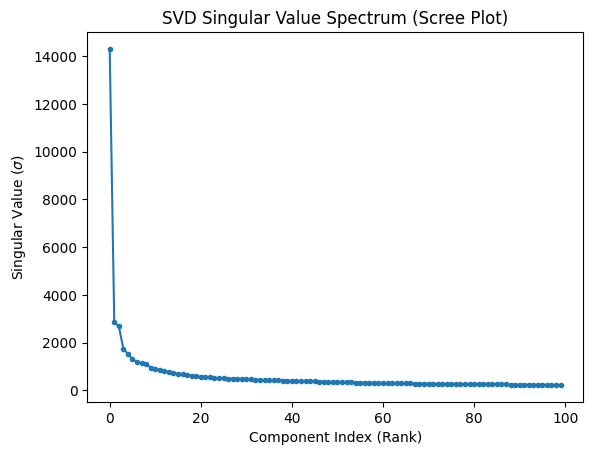

In [6]:
s_sorted = S[::-1]
# Done to see largest-to-smallest as scipy traditionally sorts singular values smallest-to-largest

plt.plot(s_sorted, marker='o', markersize=3) # Added small markers to see individual values
plt.title('SVD Singular Value Spectrum (Scree Plot)')
plt.xlabel('Component Index (Rank)')
plt.ylabel('Singular Value ($\sigma$)')
plt.show()


Since the slope is extremely negative, the matrix is of low rank.

In [7]:
for i in range(2, 7):
    v_i = U[:, ::-1][:, i]  # Extract the i-th column
    v_indices = np.argsort(v_i)  # Get indices that would sort the column
    pos_idx = v_indices[:10]
    neg_idx = v_indices[::-1][:10] #argsort sorts smallest to largest
    pos_words = [dictionary[idx] for idx in pos_idx]
    neg_words = [dictionary[idx] for idx in neg_idx]

    vector_letter = chr(95 + i) # 2 -> 'a', 3 -> 'b', etc.
    print(f"Vector {vector_letter} (v_{i})")
    print("Top 10 positive words:", pos_words)
    print("Top 10 negative words:", neg_words)
    print("-" * 40)



Vector a (v_2)
Top 10 positive words: ['specific', 'any', 'data', 'provide', 'these', 'certain', 'different', 'systems', 'its', 'use']
Top 10 negative words: ['born', 'john', 'james', 'david', 'robert', 'william', 'jr', 'george', 'thomas', 'michael']
----------------------------------------
Vector b (v_3)
Top 10 positive words: ['you', 'album', 'love', 'me', 'my', 'song', 'episode', 'your', 'vocals', 'baby']
Top 10 negative words: ['district', 'county', 'council', 'university', 'national', 'regional', 'government', 'department', 'northern', 'municipal']
----------------------------------------
Vector c (v_4)
Top 10 positive words: ['political', 'social', 'religious', 'law', 'legal', 'policy', 'rights', 'government', 'minister', 'jewish']
Top 10 negative words: ['jpg', 'km', 'located', 'near', 'road', 'river', 'lake', 'route', 'station', 'mountain']
----------------------------------------
Vector d (v_5)
Top 10 positive words: ['digital', 'science', 'software', 'technology', 'engineerin

Some of the singular vectors will not have easy-to-interpret semantics due to the noise introduced by the model not truly understanding the human language. The model, while associating words by proximity, cannot dissociate terminology by human concepts like pronouns vs adjectives vs nouns, etc. This difference causes a few terms like "the", "had" "its", etc to be introduced to the cut down data, which while not totally ruining the data, does ruin the potential interpretations of the model.

In [8]:
U_cut = U[:, :100]
U_cut = U_cut / np.linalg.norm(U_cut, ord=2, axis=1, keepdims=True)
print("Cut U shape:", U_cut.shape)
# Normalized U & truncated to top 100 singular values

Cut U shape: (10000, 100)


In [9]:
idx_woman = dictionary.index("woman")
idx_man = dictionary.index("man")

v1 = U[idx_woman, :] # Vector for "woman"
v2 = U[idx_man, :]   # Vector for "man"

v = v1 - v2

# 4. Project all words onto this gender axis using a dot product
# Since U is row-normalized, dividing by the norm of v gives the exact Cosine Similarity
similarity = np.dot(U, v) / np.linalg.norm(v)

top_indices = np.argsort(similarity)[::-1]
pos_concepts = [dictionary[idx] for idx in top_indices if dictionary[idx] not in ["woman", "man"]][:10]

bottom_indices = np.argsort(similarity)
neg_concepts = [dictionary[idx] for idx in bottom_indices if dictionary[idx] not in ["woman", "man"]][:10]

print("Closest to 'woman' end:", pos_concepts)
print("Closest to 'man' end:", neg_concepts)


Closest to 'woman' end: ['female', 'actress', 'marie', 'louise', 'anne', 'catherine', 'princess', 'margaret', 'elizabeth', 'soprano']
Closest to 'man' end: ['that', 'mr', 'drums', 'captain', 'which', 'and', 'brother', 'the', 'brothers', 'gen']


In [10]:
def get_projections(words_list, U_matrix, dictionary_list, gender_vector):
    norm_v = np.linalg.norm(gender_vector)
    projections = {}
    for word in words_list:
        if word in dictionary_list:
            idx = dictionary_list.index(word)
            u_w = U_matrix[idx, :]
            # Vector projection scalar value
            proj_val = np.dot(u_w, gender_vector) / norm_v
            projections[word] = proj_val
    return projections


def plot_projections_on_line(projections, title):
    plt.figure(figsize=(12, 3))
    # Draw a baseline at y=0
    plt.axhline(0, color='black', linewidth=1, linestyle='--')

    words = list(projections.keys())
    x_vals = list(projections.values())
    y_vals = np.zeros(len(x_vals))  # All points sit on the line

    # Plot points
    plt.scatter(x_vals, y_vals, color='purple', zorder=3)

    # Label each point with alternating heights to prevent overlap
    for i, word in enumerate(words):
        offset = 0.05 if i % 2 == 0 else -0.08
        plt.annotate(word, (x_vals[i], 0), textcoords="offset points",
                     xytext=(0, offset*100), ha='center', fontsize=10,
                     arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Projection onto v (woman - man)", fontsize=10)
    plt.xlim(min(x_vals) - 0.1, max(x_vals) + 0.1)
    # Hide the y-axis since it's a 1D line
    plt.gca().get_yaxis().set_visible(False)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


Projections (Part i): {'boy': np.float64(-0.0253), 'girl': np.float64(0.016), 'brother': np.float64(-0.0432), 'sister': np.float64(0.0139), 'king': np.float64(-0.0311), 'queen': np.float64(0.0214), 'he': np.float64(-0.0199), 'she': np.float64(0.01), 'john': np.float64(-0.025), 'mary': np.float64(0.0388), 'wall': np.float64(-0.0082), 'tree': np.float64(-0.0006)}
Projections (Part ii): {'math': np.float64(-0.0092), 'matrix': np.float64(-0.0035), 'history': np.float64(-0.0103), 'nurse': np.float64(0.0336), 'doctor': np.float64(-0.009), 'pilot': np.float64(-0.0037), 'teacher': np.float64(0.0164), 'engineer': np.float64(-0.0321), 'science': np.float64(-0.0107), 'arts': np.float64(0.0164), 'literature': np.float64(0.0111), 'bob': np.float64(-0.0125), 'alice': np.float64(0.0225)}


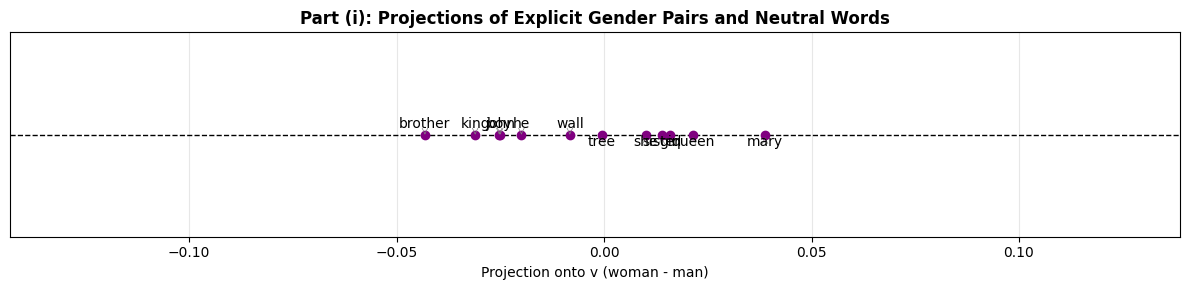

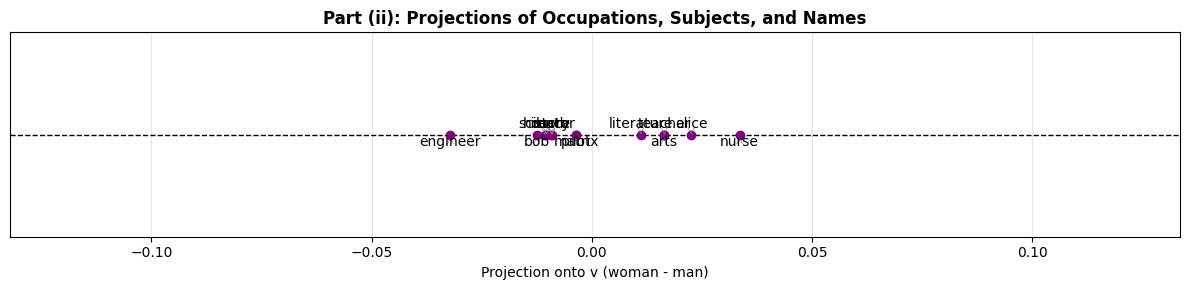

In [11]:
words_part_i = ["boy", "girl", "brother", "sister", "king", "queen", "he", "she", "john", "mary", "wall", "tree"]
words_part_ii = ["math", "matrix", "history", "nurse", "doctor", "pilot", "teacher", "engineer", "science", "arts", "literature", "bob", "alice"]

proj_i = get_projections(words_part_i, U, dictionary, v)
proj_ii = get_projections(words_part_ii, U, dictionary, v)

# Print values to the console so you can inspect them
print("Projections (Part i):", {k: round(v, 4) for k, v in proj_i.items()})
print("Projections (Part ii):", {k: round(v, 4) for k, v in proj_ii.items()})

# --- 4. Render the Plots ---
plot_projections_on_line(proj_i, "Part (i): Projections of Explicit Gender Pairs and Neutral Words")
plot_projections_on_line(proj_ii, "Part (ii): Projections of Occupations, Subjects, and Names")
